# One-way ANOVA: Condition A vs Condition C (pixel AOI, CTA)
Eye-tracking metrics per image. Each metric is compared between the two conditions.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

## 1. Load and clean the data
Converts `12.3%`, `0.59s` to numbers and `N/A` to NaN (images with no fixations).

In [2]:
BASE = Path("../..")
FILE_A = BASE / "Condition A" / "pixel" / "CTA.csv"
FILE_C = BASE / "Condition E" / "pixel" / "CTA.csv"


def load(path):
    df = pd.read_csv(path, na_values=["N/A"])
    for col in df.columns.drop("Img"):
        if not pd.api.types.is_numeric_dtype(df[col]):
            df[col] = pd.to_numeric(df[col].astype(str).str.rstrip("%s"), errors="coerce")
    return df


a = load(FILE_A)
c = load(FILE_C)
metrics = [m for m in a.columns if m != "Img"]

print(f"Condition A: {len(a)} images | Condition C: {len(c)} images")
a.head()

Condition A: 20 images | Condition C: 20 images


,Img,VAI%,Avg. TTFF,Fix. Avg. Time Spent,Fixations,Avg. Fixation Duration,Avg. FFD,K-coefficient,Avg. Revisits
0,1,0.0,NaN,0.00,0,NaN,NaN,NaN,0.00
1,2,11.4,4.19,0.59,8,0.36,0.36,0.32,0.13
2,3,24.0,3.26,0.56,16,0.32,0.34,0.30,0.20
3,4,48.6,2.74,1.15,65,0.29,0.31,0.39,0.81
4,5,6.0,5.08,0.22,3,0.22,0.22,-0.18,0.00


## 2. Run the ANOVA for every metric
NaN values are dropped per metric. Reports F, p, eta squared (effect size) and Levene's test for equal variances.

In [3]:
def one_way_anova(x, y):
    x, y = x.dropna(), y.dropna()
    f, p = stats.f_oneway(x, y)
    allv = np.concatenate([x, y])
    ss_between = len(x) * (x.mean() - allv.mean()) ** 2 + len(y) * (y.mean() - allv.mean()) ** 2
    ss_total = ((allv - allv.mean()) ** 2).sum()
    return {
        "n_A": len(x), "n_C": len(y),
        "mean_A": x.mean(), "sd_A": x.std(ddof=1),
        "mean_C": y.mean(), "sd_C": y.std(ddof=1),
        "F": f, "df": f"1, {len(x) + len(y) - 2}",
        "p": p, "eta_sq": ss_between / ss_total,
        "levene_p": stats.levene(x, y).pvalue,
    }


results = pd.DataFrame({m: one_way_anova(a[m], c[m]) for m in metrics}).T
results.index.name = "metric"
results = results.reset_index().infer_objects()
results["significant (p<.05)"] = results["p"].astype(float) < 0.05
results = results.round(4)
results

,metric,n_A,n_C,mean_A,sd_A,mean_C,sd_C,F,df,p,eta_sq,levene_p,significant (p<.05)
0,VAI%,20,18,19.2650,15.6861,28.2222,13.5106,3.5180,"1, 36",0.0688,0.0890,0.3003,False
1,Avg. TTFF,18,18,3.2989,1.0660,3.0756,0.8042,0.5035,"1, 34",0.4828,0.0146,0.3673,False
2,Fix. Avg. Time Spent,20,18,0.4535,0.2864,0.6322,0.2157,4.6377,"1, 36",0.0380,0.1141,0.4533,True
3,Fixations,20,18,15.3000,16.5819,28.0000,17.0983,5.3960,"1, 36",0.0259,0.1304,0.6764,True
4,Avg. Fixation Duration,18,18,0.2778,0.0701,0.2428,0.0361,3.5473,"1, 34",0.0682,0.0945,0.0380,False
5,Avg. FFD,18,18,0.2800,0.0719,0.2544,0.0489,1.5535,"1, 34",0.2211,0.0437,0.2217,False
6,K-coefficient,18,18,0.2072,0.4247,0.2628,0.5465,0.1160,"1, 34",0.7355,0.0034,0.7824,False
7,Avg. Revisits,20,18,0.2110,0.2599,0.4111,0.3077,4.7212,"1, 36",0.0365,0.1159,0.5603,True


## 3. Save results

In [4]:
results.to_csv("anova_A_vs_E_pixel_cta_results.csv", index=False)
print("Saved anova_A_vs_C_pixel_cta_results.csv")

Saved anova_A_vs_C_pixel_cta_results.csv


## 4. Visualize
Boxplots per metric, A vs C.

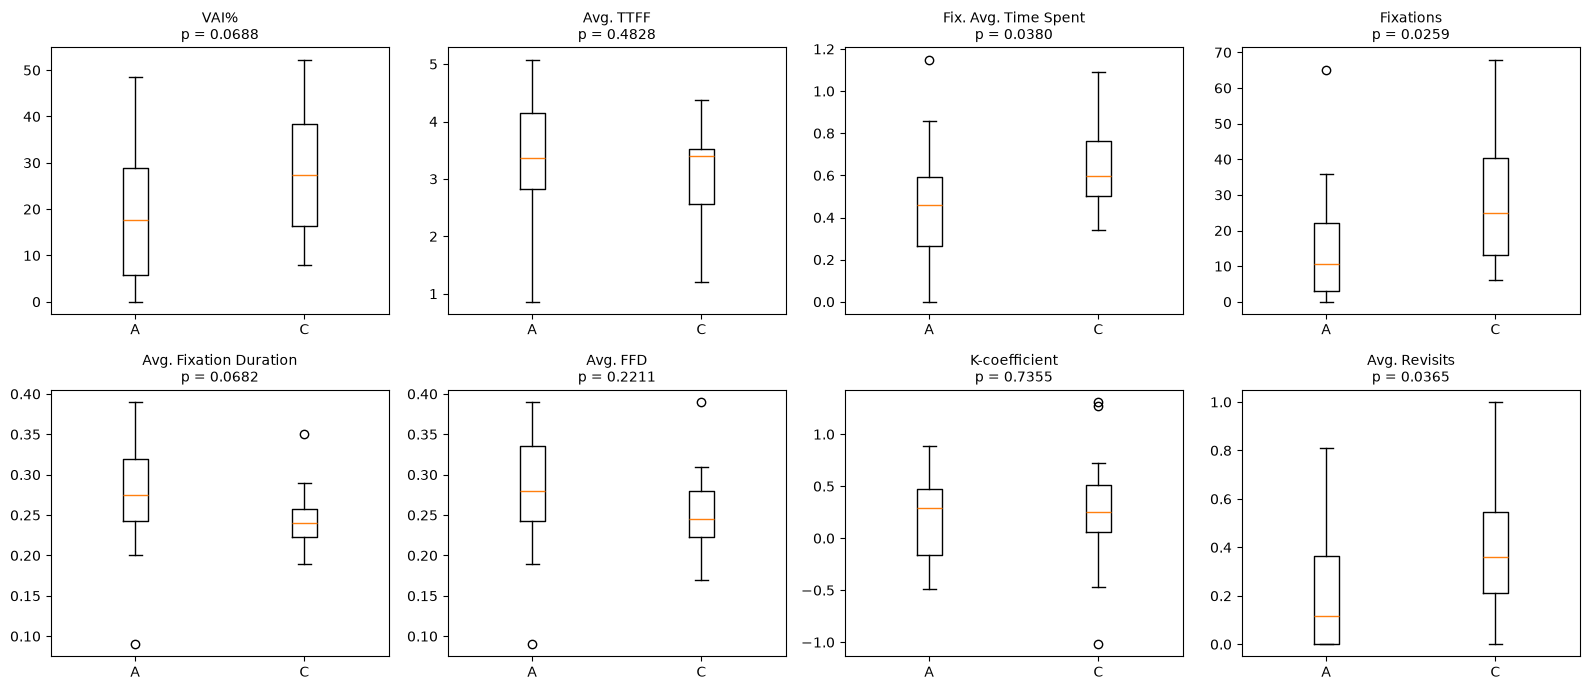

In [5]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, m in zip(axes.ravel(), metrics):
    ax.boxplot([a[m].dropna(), c[m].dropna()])
    ax.set_xticklabels(["A", "C"])
    p = results.loc[results["metric"] == m, "p"].iloc[0]
    ax.set_title(f"{m}\np = {p:.4f}", fontsize=10)
plt.tight_layout()
plt.show()